# Density-based clustering: DBSCAN and HDBSCAN

This notebook holds every density clustering run and the analysis of it. The main notebook
keeps the spherical KMeans pipeline that feeds persona generation.

**Result.** Density clustering does not work on this corpus. Across a dense parameter sweep
and at the settings the documentation recommends, the cluster count never reaches a plateau,
coherent clusters appear only when most of the corpus is discarded as noise, and at a matched
cluster count on matched rows a partitioning method separates the same data better.

That follows from the shape of the corpus, which section 5 of the main notebook measures: one
large amorphous mass with small tight satellites around it. Density methods need density
contrast. The mass has none, so they either shatter onto the satellites and drop the mass, or
merge everything into a handful of clusters.


## Setup

The pipeline head is rebuilt here so the notebook runs on its own.


In [1]:
import json, pathlib, datetime, hashlib
import numpy as np, polars as pl, pyarrow as pa, pyarrow.ipc as pa_ipc
import cupy as cp, cuml
from cuml.metrics.cluster import silhouette_score
from cuml.neighbors import NearestNeighbors
import matplotlib.pyplot as plt, matplotlib.lines as mlines
from matplotlib.patches import Patch

MAIN_NB    = "/home/stephen/Project-Sim/data_load_personae.ipynb"
EMBEDDINGS = "/datapool/analysis_data/proj-sim/embeddings/2026-08-08/embeddings_43e3b506acd198f3.arrow"
WORKING    = pathlib.Path("/datapool/analysis_data/proj-sim/working_state")

SAMPLE_SIZE, SUBSAMPLE_SEED, RANDOM_SEED = 100_000, 67, 42
N_POSTS, PCA_VARIANCE = 500, 0.90
DATA_HASH = "43e3b506acd198f3"

# spherical_kmeans comes from the main notebook, so the two cannot drift apart.
_impl = "".join([c["source"] for c in json.load(open(MAIN_NB))["cells"]
                 if c["id"] == "spherical-kmeans-impl"][0])
_ns = {"np": np, "cp": cp, "cuml": cuml}
exec(_impl, _ns)
spherical_kmeans = _ns["spherical_kmeans"]
n_init = 10

with pa_ipc.open_file(EMBEDDINGS) as reader:
    _table = reader.read_all()
_col  = _table["embedding"].combine_chunks()
_full = (_col.flatten().to_numpy(zero_copy_only=False)
              .reshape(len(_col), -1).astype(np.float32, copy=False))
_idx  = (pl.DataFrame({"_": np.zeros(len(_full), dtype=np.int8)}).with_row_index("_idx")
           .sample(n=SAMPLE_SIZE, seed=SUBSAMPLE_SEED)["_idx"].to_numpy())
embeddings_raw = _full[_idx]
del _full, _table, _col

_probe = cuml.PCA(n_components=embeddings_raw.shape[1]).fit(embeddings_raw)
n_components = int(np.searchsorted(np.cumsum(np.asarray(_probe.explained_variance_ratio_)),
                                   PCA_VARIANCE)) + 1
del _probe
embeddings       = np.asarray(cuml.PCA(n_components=n_components).fit_transform(embeddings_raw))
embeddings_pca50 = np.asarray(cuml.PCA(n_components=50).fit_transform(embeddings_raw))

def _l2_normalize(X):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return (X / np.maximum(n, 1e-12)).astype(np.float32)

_pca_label   = f"PCA{n_components}"
_pca50_label = f"PCA{embeddings_pca50.shape[1]}"
_kmeans_spaces = {_pca_label: _l2_normalize(embeddings), _pca50_label: _l2_normalize(embeddings_pca50)}

# Post ids come from the checkpoint the main notebook writes, because a usable cluster is
# counted in distinct posts and rebuilding them here would repeat the whole cleaning stage.
_dirs = sorted(WORKING.glob("????-??-??"), reverse=True) if WORKING.exists() else []
if not _dirs:
    raise FileNotFoundError(f"No checkpoint under {WORKING}. Run the main notebook first.")
posts = pl.read_parquet(_dirs[0] / "posts_sample.parquet")
assert len(posts) == SAMPLE_SIZE, f"checkpoint holds {len(posts):,} rows, expected {SAMPLE_SIZE:,}"
_post_code    = (posts["id"].cast(pl.Categorical).to_physical()
                            .cast(pl.Int64).fill_null(-1).to_numpy())
_n_post_codes = max(int(_post_code.max()) + 1, 1)
print(f"{len(posts):,} rows from {_dirs[0].name} | {n_components} PCA dims")

def _nunique_per_cluster(labels, codes, n_codes, k):
    keep  = codes >= 0
    pairs = np.unique(labels[keep].astype(np.int64) * n_codes + codes[keep])
    return np.bincount(pairs // n_codes, minlength=k)


100,000 rows from 2026-08-21 | 184 PCA dims


In [2]:
# umap-learn, "Using UMAP for Clustering": n_neighbors=30, min_dist=0.0, n_components=2.
# https://umap-learn.readthedocs.io/en/latest/clustering.html
UMAP_DIMS, UMAP_N_NEIGHBORS, UMAP_MIN_DIST = 2, 30, 0.0

def _fit_umap(source_embs):
    return np.asarray(cuml.manifold.UMAP(
        n_components=UMAP_DIMS, n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST,
        random_state=42, metric="cosine").fit_transform(source_embs))

embeddings_umap        = _fit_umap(embeddings_raw)
embeddings_pcavar_umap = _fit_umap(embeddings)
embeddings_pca50_umap  = _fit_umap(embeddings_pca50)
print("UMAP fitted on all three input spaces")


UMAP fitted on all three input spaces


In [3]:
_COS_BINS = np.linspace(-0.4, 1.0, 141)

def _centroid_cosines(embs, labels, centroids=None):
    """Cosine similarity from every clustered row to its own cluster centroid.

    centroids=None takes the cluster mean, which is what DBSCAN and HDBSCAN need. Noise rows
    are dropped. Cosine ignores vector length, so unit-length KMeans centroids and plain
    density means compare directly.
    """
    keep = labels != -1
    lbl, vecs = labels[keep], embs[keep]
    if centroids is None:
        ids = np.unique(lbl)
        lbl = np.searchsorted(ids, lbl)
        counts    = np.maximum(np.bincount(lbl, minlength=len(ids)), 1)[:, None]
        centroids = np.stack([np.bincount(lbl, weights=vecs[:, j], minlength=len(ids))
                              for j in range(vecs.shape[1])], axis=1) / counts
    c = centroids[lbl]
    denom = np.linalg.norm(vecs, axis=1) * np.linalg.norm(c, axis=1)
    return (vecs * c).sum(axis=1) / np.maximum(denom, 1e-12)

_null_rng = np.random.default_rng(RANDOM_SEED)

def _make_nulls(X):
    """Two matrices shaped like X with no clustering in them."""
    return {
        "gaussian":       (_null_rng.standard_normal(X.shape).astype(np.float32)
                           * X.std(axis=0, keepdims=True)),
        "column shuffle": np.column_stack([_null_rng.permutation(X[:, j])
                                           for j in range(X.shape[1])]).astype(np.float32),
    }

def _rand_eval(labels, score_space):
    """The same four numbers for every clustering, real or null."""
    keep = labels != -1
    ids  = np.unique(labels[keep])
    out  = dict(k=len(ids), noise=float((~keep).mean()) * 100, sil=float("nan"), usable=0)
    if len(ids) == 0:
        return out
    compact = np.searchsorted(ids, labels[keep]).astype(np.int32)
    out["usable"] = int((_nunique_per_cluster(compact, _post_code[keep], _n_post_codes,
                                              len(ids)) >= N_POSTS).sum())
    if len(ids) >= 2:
        out["sil"] = float(silhouette_score(np.ascontiguousarray(score_space[keep],
                                                                 dtype=np.float32),
                                            compact, metric="cosine"))
    return out

# Line style keys the condition wherever a null is drawn beside real data.
_cond_style = {"real": ("-", 1.6), "gaussian": (":", 1.2), "column shuffle": ("--", 1.2)}


### Density-based clustering: DBSCAN and HDBSCAN

DBSCAN and HDBSCAN find clusters based on local density which maybe fixes the cluster size problem we observed in PCA/UMAP above.

It excludes noise which maybe is a problem.

In [4]:
# DBSCAN. minPts = 2 * dimensions (Ester et al. 1996; Schubert et al. 2017 recommends raising
# it on noisy data). eps comes from the elbow of the k-distance graph, which is the method
# scikit-learn points to and which _knee_eps computes below.
DBSCAN_MIN_SAMPLES = 2 * UMAP_DIMS
# The sweep stays, because it shows the coverage-against-tightness trade-off. The selected
# value is the elbow, added per space in the fit cell.
DBSCAN_EPS_VALUES  = [0.2, 0.5, 1.0, 2.0, 3.0, 5.0]

# HDBSCAN. umap-learn's clustering example uses min_samples=10 with min_cluster_size=500 on
# 70,000 rows, which is 0.71% of them. cuML leaves min_samples at min_cluster_size when it is
# unset, so it has to be given explicitly.
HDBSCAN_MIN_SAMPLES = 10
HDBSCAN_DOC_SIZE    = max(int(round(0.0071 * SAMPLE_SIZE)), 2)
HDBSCAN_MIN_SIZES   = sorted({50, 100, 200, 500, HDBSCAN_DOC_SIZE, 1000})  # cuML cap: <= 1023

N_POSTS_DENSITY = 3   # representative posts shown per cluster in display cells

print(f"DBSCAN min_samples={DBSCAN_MIN_SAMPLES} (2 x {UMAP_DIMS} dims) | "
      f"HDBSCAN min_samples={HDBSCAN_MIN_SAMPLES}, "
      f"documented min_cluster_size={HDBSCAN_DOC_SIZE} (0.71% of {SAMPLE_SIZE:,})")


DBSCAN min_samples=4 (2 x 2 dims) | HDBSCAN min_samples=10, documented min_cluster_size=710 (0.71% of 100,000)


#### Normalize UMAP scale across spaces

`DBSCAN_EPS_VALUES` is swept once and applied to all three UMAP spaces below, but `eps` is an absolute distance in each embedding's own coordinates, and separate UMAP fits have no shared scale. `eps=1.0` can mean "tight neighbourhood" in one space and "most of the cluster" in another, making the eps-sweep comparison across spaces invalid unless we fix that.

We rescale each UMAP embedding by its own median nearest-neighbour distance, so `eps` is expressed in comparable units (multiples of typical local point spacing) in every space. `min_cluster_size` (HDBSCAN) doesn't need this — it's a point count, not a distance.

In [5]:
from cuml.neighbors import NearestNeighbors

# Ester et al. 1996 and Schubert et al. 2017 read eps off the k-distance graph with
# k = minPts - 1. Both functions below use that k.
_KDIST_K = max(DBSCAN_MIN_SAMPLES - 1, 1)

def _k_distances(embs):
    # One extra neighbour, because the first hit any point returns is itself.
    nn = NearestNeighbors(n_neighbors=_KDIST_K + 1)
    nn.fit(embs)
    dists, _ = nn.kneighbors(embs)
    return np.sort(np.asarray(dists)[:, -1])

def _normalize_scale(embs):
    """Scale so one unit is the median k-distance, which makes eps mean the same in every space."""
    median_nn_dist = float(np.median(_k_distances(embs)))
    return embs / median_nn_dist, median_nn_dist

KDIST_TRIM = 99.0

def _knee_eps(scaled_embs, trim=KDIST_TRIM):
    """eps at the elbow of the sorted k-distance curve, in median-k-distance units.

    The elbow is the point furthest below the straight line joining the two ends of the curve,
    after scaling both axes to [0, 1].

    The top 100 - trim percent of k-distances is dropped first. UMAP leaves a few points tens
    of thousands of units from their neighbours: the median k-distance here is 1.0 and the
    maximum is 65,420. Those points set the scale of the curve and drag the elbow up to 56,
    which merges every cluster. Trimming at the 99th percentile puts it at 1.87.
    """
    kd = _k_distances(scaled_embs)
    kd = kd[kd <= np.percentile(kd, trim)]
    x  = np.linspace(0.0, 1.0, len(kd))
    y  = (kd - kd[0]) / max(kd[-1] - kd[0], 1e-12)
    return float(kd[int(np.argmax(x - y))])

embeddings_umap,        _median_nn_umap        = _normalize_scale(embeddings_umap)
embeddings_pcavar_umap, _median_nn_pcavar_umap = _normalize_scale(embeddings_pcavar_umap)
embeddings_pca50_umap,  _median_nn_pca50_umap  = _normalize_scale(embeddings_pca50_umap)

print(f"Median NN distance before normalization — raw→UMAP: {_median_nn_umap:.4f}, "
      f"PCA→UMAP: {_median_nn_pcavar_umap:.4f}, PCA50→UMAP: {_median_nn_pca50_umap:.4f}")


Median NN distance before normalization — raw→UMAP: 0.0189, PCA→UMAP: 0.0191, PCA50→UMAP: 0.0200


In [6]:
_density_umap_spaces = {
    f"{_pca_label}→UMAP":   embeddings_pcavar_umap,
    f"{_pca50_label}→UMAP": embeddings_pca50_umap,
    "384→UMAP":              embeddings_umap,
}
_density_score_spaces = {
    f"{_pca_label}→UMAP":   embeddings,
    f"{_pca50_label}→UMAP": embeddings_pca50,
    "384→UMAP":              embeddings_raw,
}

#### DBSCAN


In [7]:
dbscan_runs = {sname: {} for sname in _density_umap_spaces}
# The elbow lands in a different place in each space, so it is added to that space's sweep.
knee_eps = {s: round(_knee_eps(e), 2) for s, e in _density_umap_spaces.items()}
print("eps at the k-distance elbow:", knee_eps)

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for eps in sorted(set(DBSCAN_EPS_VALUES) | {knee_eps[space_name]}):
        db   = cuml.cluster.DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean")
        lbls = db.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  eps={eps}  {space_name}  k={n_k}  noise={nf:.1%}")
        dbscan_runs[space_name][eps] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted DBSCAN: {len(DBSCAN_EPS_VALUES)} eps values x {len(_density_umap_spaces)} spaces")


eps at the k-distance elbow: {'PCA184→UMAP': 1.87, 'PCA50→UMAP': 1.8, '384→UMAP': 1.82}
[2026-08-21 15:52:51.674] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=0.2  PCA184→UMAP  k=132  noise=99.2%
[2026-08-21 15:52:51.874] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=0.5  PCA184→UMAP  k=2372  noise=84.6%
[2026-08-21 15:52:52.039] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=1.0  PCA184→UMAP  k=4727  noise=36.0%
[2026-08-21 15:52:52.216] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=1.87  PCA184→UMAP  k=1156  noise=7.5%
[2026-08-21 15:52:52.402] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


...

  eps=1.0  384→UMAP  k=5130  noise=35.0%
[2026-08-21 15:52:54.757] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=1.82  384→UMAP  k=1262  noise=7.6%
[2026-08-21 15:52:54.951] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=2.0  384→UMAP  k=1069  noise=6.1%
[2026-08-21 15:52:55.140] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=3.0  384→UMAP  k=683  noise=2.5%
[2026-08-21 15:52:55.323] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=5.0  384→UMAP  k=472  noise=0.8%

Fitted DBSCAN: 6 eps values x 3 spaces


#### HDBSCAN


In [8]:
hdbscan_runs = {sname: {} for sname in _density_umap_spaces}

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for mcs in HDBSCAN_MIN_SIZES:
        hdb  = cuml.cluster.HDBSCAN(min_cluster_size=mcs, min_samples=HDBSCAN_MIN_SAMPLES,
                                    metric="euclidean")
        lbls = hdb.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  min_cluster_size={mcs}  {space_name}  k={n_k}  noise={nf:.1%}")
        hdbscan_runs[space_name][mcs] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted HDBSCAN: {len(HDBSCAN_MIN_SIZES)} min_cluster_size values x {len(_density_umap_spaces)} spaces")


  min_cluster_size=50  PCA184→UMAP  k=273  noise=39.3%


  min_cluster_size=100  PCA184→UMAP  k=106  noise=29.6%


  min_cluster_size=200  PCA184→UMAP  k=57  noise=33.0%


  min_cluster_size=500  PCA184→UMAP  k=9  noise=7.4%


  min_cluster_size=710  PCA184→UMAP  k=5  noise=7.2%


...

  min_cluster_size=100  384→UMAP  k=143  noise=44.9%


  min_cluster_size=200  384→UMAP  k=33  noise=9.0%


  min_cluster_size=500  384→UMAP  k=11  noise=9.7%


  min_cluster_size=710  384→UMAP  k=7  noise=12.2%


  min_cluster_size=1000  384→UMAP  k=4  noise=14.6%

Fitted HDBSCAN: 6 min_cluster_size values x 3 spaces


#### Cluster quality analysis


In [9]:
def _sil_no_noise(embs, labels):
    mask   = labels != -1
    unique = set(labels[mask])
    if mask.sum() < 2 or len(unique) < 2:
        return float("nan")
    return round(float(silhouette_score(
        embs[mask].astype(np.float32), labels[mask].astype(np.int32), metric="euclidean"
    )), 3)

def _cos_no_noise(score_embs, labels):
    unique_ids = [l for l in np.unique(labels) if l != -1]
    if not unique_ids:
        return float("nan")
    sims = []
    for cid in unique_ids:
        idx      = np.where(labels == cid)[0]
        if len(idx) < 2:
            continue
        cluster  = score_embs[idx]
        centroid = cluster.mean(axis=0)
        norm_c   = float(np.linalg.norm(centroid))
        if norm_c == 0:
            continue
        dots  = cluster @ centroid
        norms = np.linalg.norm(cluster, axis=1) * norm_c
        sims.extend((dots / norms).tolist())
    return float(np.mean(sims)) if sims else float("nan")

def _score_density_runs(runs_dict):
    quality = {}
    for sname, param_dict in runs_dict.items():
        quality[sname] = {}
        for param, lbls in sorted(param_dict.items()):
            quality[sname][param] = dict(
                sil     = _sil_no_noise(_density_umap_spaces[sname], lbls),
                avg_cos = _cos_no_noise(_density_score_spaces[sname], lbls),
                n_k     = len([l for l in np.unique(lbls) if l != -1]),
                noise   = round(float((lbls == -1).sum()) / len(lbls), 3),
            )
    return quality

dbscan_quality  = _score_density_runs(dbscan_runs)
hdbscan_quality = _score_density_runs(hdbscan_runs)


We can remove anything with noise $>5%$ or $k<9$ as not useful for our purposes.

In [10]:
def _filter_density_quality(quality, runs):
    filtered_quality = {}
    filtered_runs    = {}
    for sname, param_dict in quality.items():
        kept_quality = {}
        kept_runs    = {}
        for param, metrics in param_dict.items():
            if metrics['noise'] > 0.05 or metrics['n_k'] < 9:
                continue
            kept_quality[param] = metrics
            kept_runs[param]    = runs[sname][param]
        filtered_quality[sname] = kept_quality
        filtered_runs[sname]    = kept_runs
    return filtered_quality, filtered_runs

dbscan_quality_f,  dbscan_runs_f  = _filter_density_quality(dbscan_quality,  dbscan_runs)
hdbscan_quality_f, hdbscan_runs_f = _filter_density_quality(hdbscan_quality, hdbscan_runs)

for algo, q in [('DBSCAN', dbscan_quality_f), ('HDBSCAN', hdbscan_quality_f)]:
    total = sum(len(v) for v in q.values())
    print(f"{algo}: {total} configurations kept")
    for sname, params in q.items():
        for param, m in sorted(params.items()):
            print(f"  {sname}  param={param}  k={m['n_k']}  noise={m['noise']:.1%}  sil={m['sil']:.3f}")


DBSCAN: 6 configurations kept
  PCA184→UMAP  param=3.0  k=569  noise=2.5%  sil=-0.496
  PCA184→UMAP  param=5.0  k=367  noise=0.9%  sil=-0.417
  PCA50→UMAP  param=3.0  k=476  noise=2.0%  sil=-0.530
  PCA50→UMAP  param=5.0  k=314  noise=0.7%  sil=-0.415
  384→UMAP  param=3.0  k=683  noise=2.5%  sil=-0.381
  384→UMAP  param=5.0  k=472  noise=0.8%  sil=-0.275
HDBSCAN: 0 configurations kept


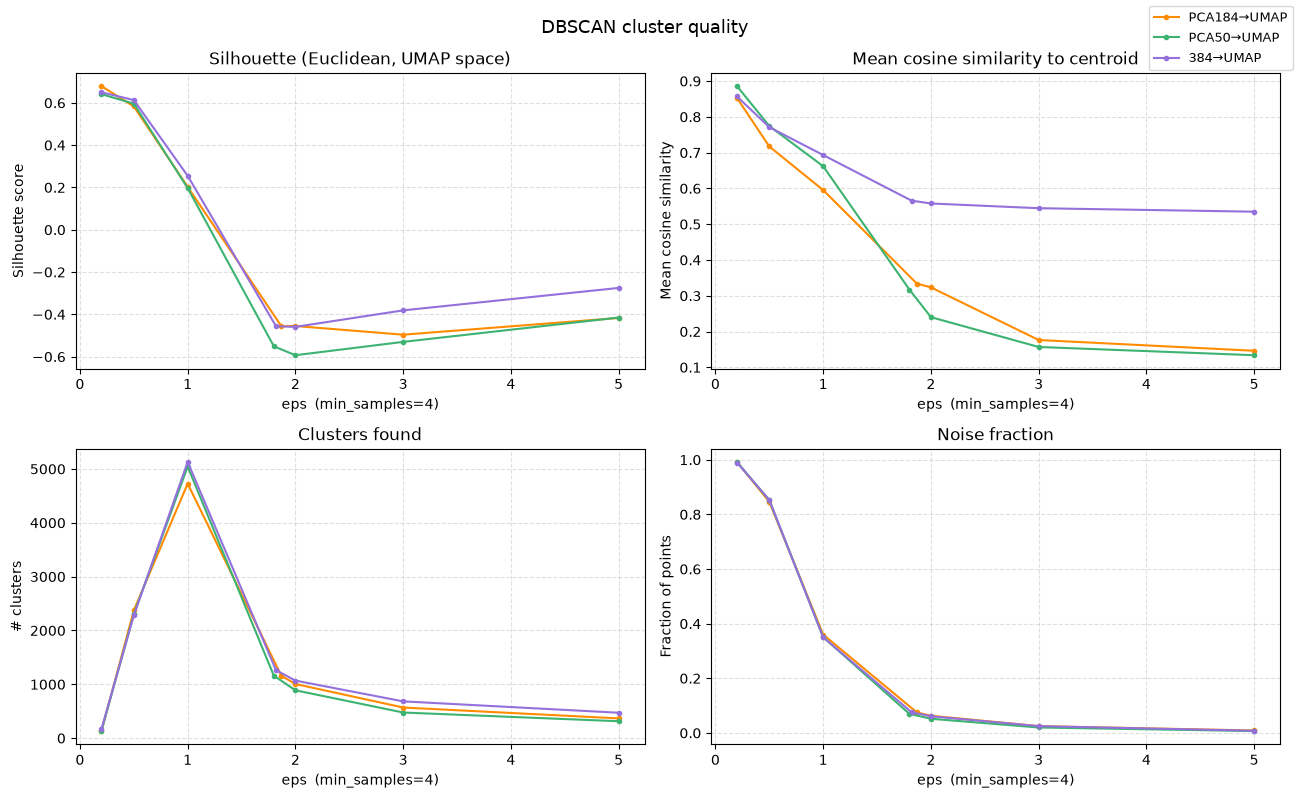

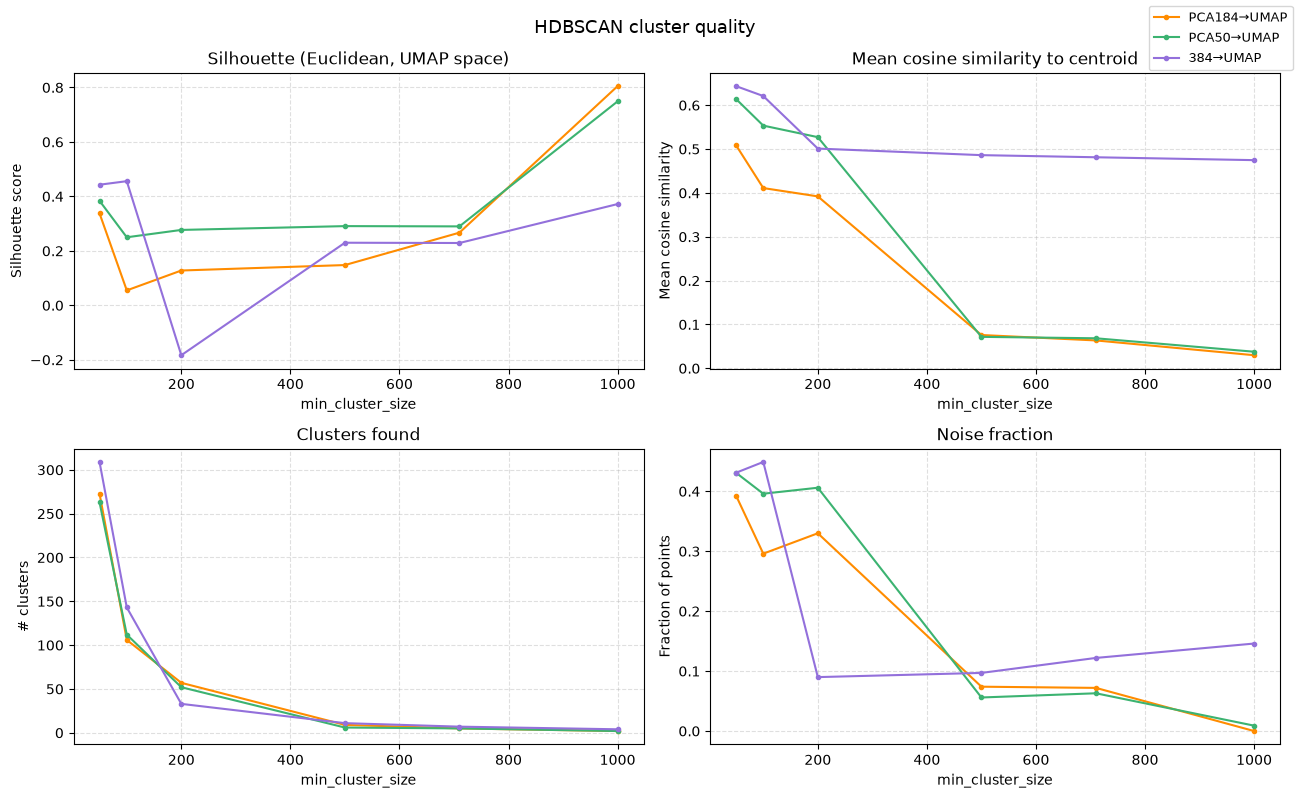

In [11]:
_space_colors = {
    f"{_pca_label}→UMAP":   "darkorange",
    f"{_pca50_label}→UMAP": "mediumseagreen",
    "384→UMAP":              "mediumpurple",
}

def _plot_density_quality(quality, param_label, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    (ax_sil, ax_cos), (ax_nk, ax_nf) = axes

    for sname, param_dict in quality.items():
        xs   = sorted(param_dict.keys())
        c    = _space_colors[sname]
        sils = [param_dict[x]["sil"]     for x in xs]
        coss = [param_dict[x]["avg_cos"] for x in xs]
        nks  = [param_dict[x]["n_k"]     for x in xs]
        nfs  = [param_dict[x]["noise"]   for x in xs]

        def _line(ax, ys):
            pairs = [(x, y) for x, y in zip(xs, ys) if not (isinstance(y, float) and np.isnan(y))]
            if pairs:
                vx, vy = zip(*pairs)
                ax.plot(vx, vy, ".-", color=c, label=sname)

        _line(ax_sil, sils)
        _line(ax_cos, coss)
        _line(ax_nk,  nks)
        _line(ax_nf,  nfs)

    for ax, title, ylabel in [
        (ax_sil, "Silhouette (Euclidean, UMAP space)",  "Silhouette score"),
        (ax_cos, "Mean cosine similarity to centroid",   "Mean cosine similarity"),
        (ax_nk,  "Clusters found",                      "# clusters"),
        (ax_nf,  "Noise fraction",                      "Fraction of points"),
    ]:
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(param_label)
        ax.grid(linestyle="--", alpha=0.4)

    handles = [
        mlines.Line2D([], [], color=c, marker=".", label=sname)
        for sname, c in _space_colors.items()
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9)
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

_plot_density_quality(dbscan_quality,  f"eps  (min_samples={DBSCAN_MIN_SAMPLES})", "DBSCAN cluster quality")
_plot_density_quality(hdbscan_quality, "min_cluster_size",                          "HDBSCAN cluster quality")


#### How many clusters are still usable

The same test the KMeans panel uses, applied to every density configuration. A cluster needs
at least `N_POSTS` distinct posts to fill a persona dump, so clusters below that are discarded
and the posts in them are wasted. Noise can never fill a dump, so it counts as stranded too.

DBSCAN and HDBSCAN are swept over one parameter each, across the three UMAP spaces, so a
"configuration" here is one (space, parameter) pair.


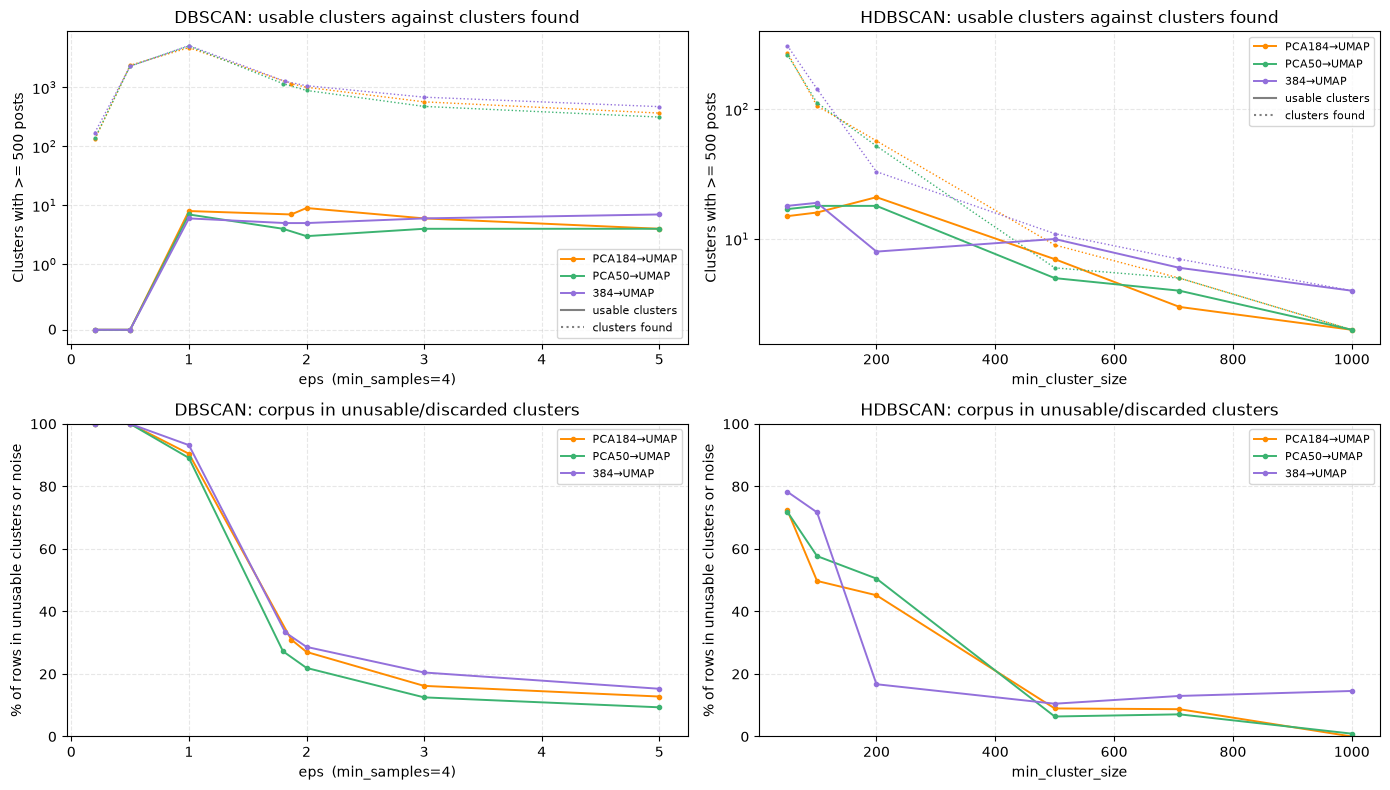

DBSCAN: 15 of 21 configurations produced at least one usable cluster | best: PCA184→UMAP param=2.0 -> 9 usable of 1006 found, 27.0% stranded
HDBSCAN: 18 of 18 configurations produced at least one usable cluster | best: PCA184→UMAP param=200 -> 21 usable of 57 found, 45.2% stranded


In [12]:
# Reuses _post_code and _nunique_per_cluster from the extended k sweep above, so the post
# counts are the same measure used for KMeans: distinct post ids, not chunk rows.
def _density_usable(labels):
    """Return (usable clusters, clusters found, % of corpus stranded) for one run.

    Density labels are not 0..k-1: noise is -1 and cuML can leave gaps. We compact them
    before counting so bincount stays dense.
    """
    keep = labels != -1
    ids  = np.unique(labels[keep])
    if len(ids) == 0:
        return 0, 0, 100.0
    compact    = np.searchsorted(ids, labels[keep])
    posts_per  = _nunique_per_cluster(compact, _post_code[keep], _n_post_codes, len(ids))
    chunks_per = np.bincount(compact, minlength=len(ids))
    usable     = posts_per >= N_POSTS
    stranded   = (len(labels) - int(chunks_per[usable].sum())) / len(labels) * 100
    return int(usable.sum()), len(ids), float(stranded)

density_usable = {}   # (method, space, param) -> dict, reused by the bar chart below
for _method, _runs in (("DBSCAN", dbscan_runs), ("HDBSCAN", hdbscan_runs)):
    for _sname, _param_dict in _runs.items():
        for _param, _lbls in sorted(_param_dict.items()):
            _u, _found, _stranded = _density_usable(_lbls)
            density_usable[(_method, _sname, _param)] = {
                "usable": _u, "found": _found, "stranded": _stranded,
                "noise": float((_lbls == -1).sum()) / len(_lbls) * 100,
            }

_specs = [("DBSCAN",  f"eps  (min_samples={DBSCAN_MIN_SAMPLES})"),
          ("HDBSCAN", "min_cluster_size")]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), squeeze=False)

for col, (method, xlabel) in enumerate(_specs):
    ax_n, ax_lost = axes[0][col], axes[1][col]
    for sname, colour in _space_colors.items():
        params = sorted(p for (m, s, p) in density_usable if m == method and s == sname)
        if not params:
            continue
        rows = [density_usable[(method, sname, p)] for p in params]
        ax_n.plot(params, [r["found"] for r in rows], ":", color=colour, linewidth=1,
                  marker=".", markersize=4)
        ax_n.plot(params, [r["usable"] for r in rows], "-", color=colour, linewidth=1.4,
                  marker="o", markersize=3, label=sname)
        ax_lost.plot(params, [r["stranded"] for r in rows], "-", color=colour, linewidth=1.4,
                     marker="o", markersize=3, label=sname)

    # Clusters found runs into the hundreds while usable stays in single or low double
    # digits, so a linear axis flattens the line that matters. symlog keeps 0 plottable.
    ax_n.set_yscale("symlog", linthresh=1)
    ax_n.set_ylabel(f"Clusters with >= {N_POSTS} posts")
    ax_n.set_title(f"{method}: usable clusters against clusters found")
    ax_lost.set_ylabel("% of rows in unusable clusters or noise")
    ax_lost.set_title(f"{method}: corpus in unusable/discarded clusters")
    for ax in (ax_n, ax_lost):
        ax.set_xlabel(xlabel)
        ax.grid(linestyle="--", alpha=0.3)
        ax.legend(fontsize=8)

    # Colour keys the space, line style keys the quantity. Both belong in the legend.
    _style_keys = [mlines.Line2D([], [], color="grey", linestyle="-",  label="usable clusters"),
                   mlines.Line2D([], [], color="grey", linestyle=":", label="clusters found")]
    ax_n.legend(handles=ax_n.get_legend_handles_labels()[0] + _style_keys, fontsize=8)
    ax_lost.set_ylim(0, 100)

plt.tight_layout()
plt.show()

for method, _ in _specs:
    _rows = {k: v for k, v in density_usable.items() if k[0] == method}
    _best = max(_rows.items(), key=lambda kv: kv[1]["usable"])
    print(f"{method}: {sum(1 for v in _rows.values() if v['usable'] > 0)} of {len(_rows)} "
          f"configurations produced at least one usable cluster | best: {_best[0][1]} "
          f"param={_best[0][2]} -> {_best[1]['usable']} usable of {_best[1]['found']} found, "
          f"{_best[1]['stranded']:.1f}% stranded")


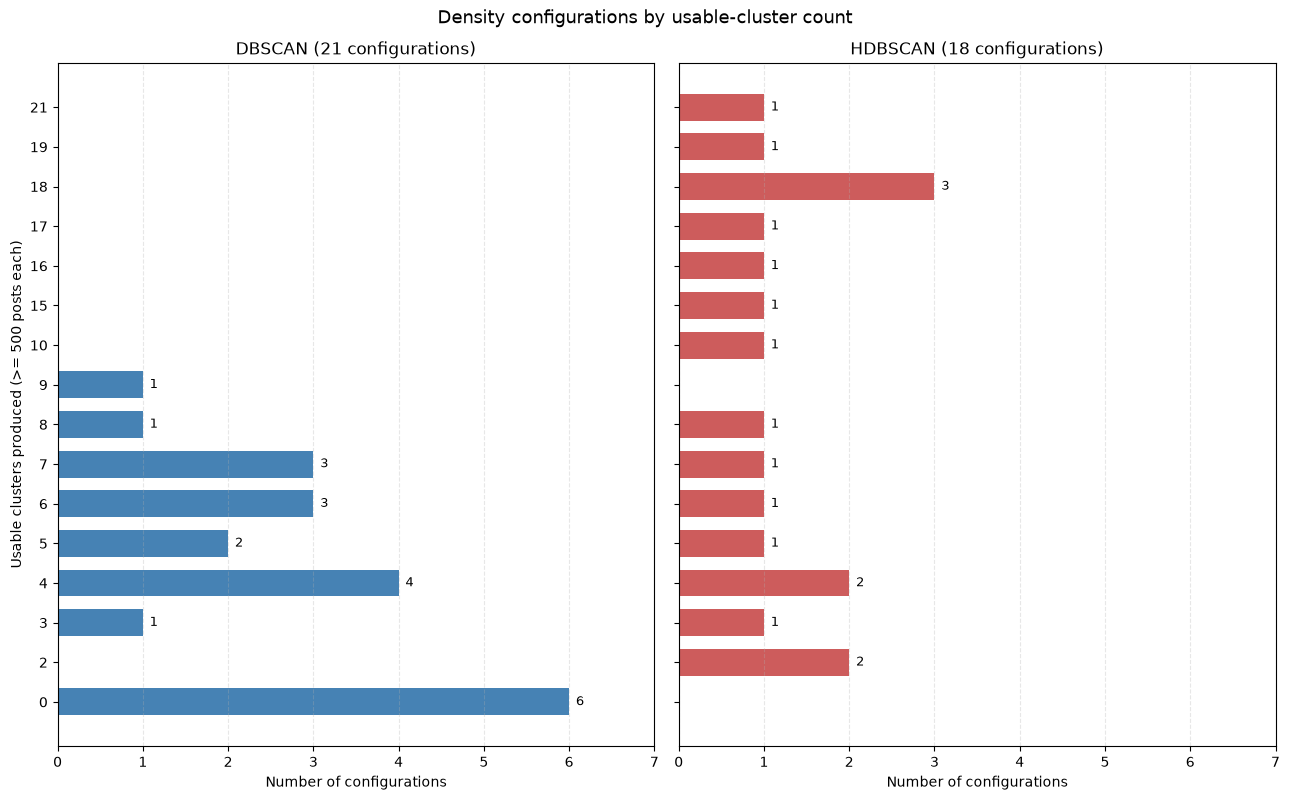

DBSCAN: 6 of 21 configurations produced no usable cluster at all
HDBSCAN: 0 of 18 configurations produced no usable cluster at all


In [13]:
# How many configurations land on each usable-cluster count, one panel per method.
# Horizontal bars: the counts on the y axis are labels, not a measured scale, and they read
# straight across. Both panels share the y categories so the two methods line up.
_counts  = sorted({v["usable"] for v in density_usable.values()})
_methods = [("DBSCAN", "steelblue"), ("HDBSCAN", "indianred")]
_per_method = {
    m: [sum(1 for (mm, _s, _p), v in density_usable.items() if mm == m and v["usable"] == c)
        for c in _counts]
    for m, _c in _methods
}

fig, axes = plt.subplots(1, len(_methods), figsize=(13, max(3.2, 0.42 * len(_counts) + 1.4)),
                         sharey=True, squeeze=False)
_y    = np.arange(len(_counts))
_xmax = max(max(v) for v in _per_method.values()) + 1

for ax, (method, colour) in zip(axes[0], _methods):
    vals  = _per_method[method]
    total = sum(1 for (mm, _s, _p) in density_usable if mm == method)
    ax.barh(_y, vals, height=0.68, color=colour)
    for y, v in zip(_y, vals):
        if v:
            ax.text(v + 0.08, y, str(v), va="center", fontsize=9)
    ax.set_yticks(_y)
    ax.set_yticklabels([str(c) for c in _counts])
    ax.set_xlabel("Number of configurations")
    ax.set_xlim(0, _xmax)
    ax.set_title(f"{method} ({total} configurations)")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

axes[0][0].set_ylabel(f"Usable clusters produced (>= {N_POSTS} posts each)")
fig.suptitle("Density configurations by usable-cluster count", fontsize=13)
plt.tight_layout()
plt.show()

for method, _ in _methods:
    rows  = {k: v for k, v in density_usable.items() if k[0] == method}
    zero  = sum(1 for v in rows.values() if v["usable"] == 0)
    print(f"{method}: {zero} of {len(rows)} configurations produced no usable cluster at all")


#### Cosine similarity distributions

The same measure applied to the density runs, so they read against the KMeans panels.
Centroids here are plain cluster means, and noise is dropped rather than treated as a cluster.
Only the configurations that pass the noise and cluster-count filter are drawn. The rest hold
too few clusters, or almost nothing but noise.


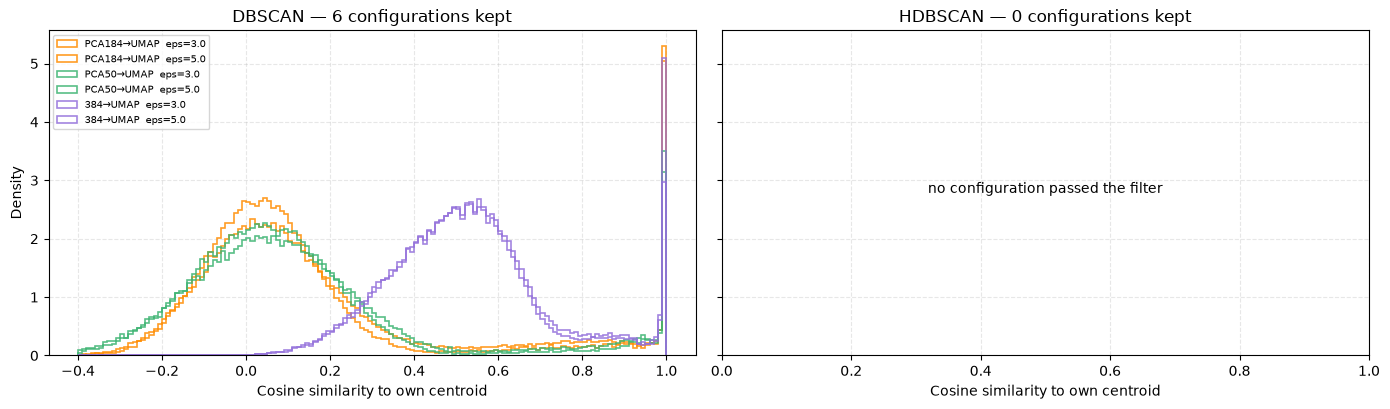

In [14]:
_density_cos_sets = [("DBSCAN", "eps", dbscan_runs_f), ("HDBSCAN", "min_cluster_size", hdbscan_runs_f)]

fig, axes = plt.subplots(1, len(_density_cos_sets), figsize=(7 * len(_density_cos_sets), 4.2),
                         squeeze=False, sharey=True)

for ax, (method, param_label, runs) in zip(axes[0], _density_cos_sets):
    drawn = 0
    for sname, param_dict in runs.items():
        for param, lbls in sorted(param_dict.items()):
            sims = _centroid_cosines(_density_score_spaces[sname], lbls)
            if not len(sims):
                continue
            ax.hist(sims, bins=_COS_BINS, density=True, histtype="step", linewidth=1.2,
                    color=_space_colors[sname], alpha=0.85,
                    label=f"{sname}  {param_label}={param}")
            drawn += 1
    ax.set_xlabel("Cosine similarity to own centroid")
    ax.set_title(f"{method} — {drawn} configurations kept")
    ax.grid(linestyle="--", alpha=0.3)
    if drawn:
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "no configuration passed the filter", ha="center", transform=ax.transAxes)

axes[0][0].set_ylabel("Density")
plt.tight_layout()
plt.show()


### Cluster tightness across methods

Each method is represented by the configuration that produced the most usable clusters. All
three are scored in the same space, so only the labels differ between the curves.

Share of rows kept matters as much as the shape. DBSCAN and HDBSCAN drop their noise, so they
are scored on an easier subset than KMeans, which has to place every row.


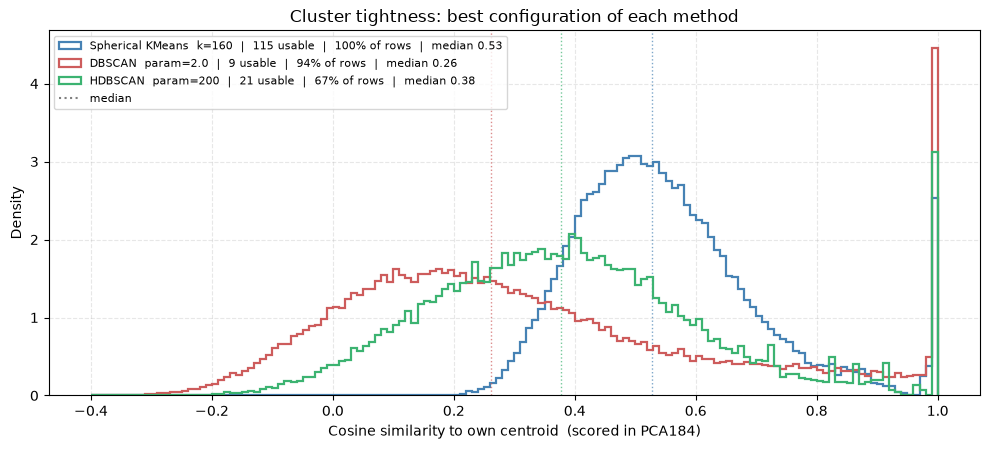

Spherical KMeans  k=160      rows=100,000  usable=115  p10=0.379  median=0.528  p90=0.742
DBSCAN  param=2.0            rows= 93,662  usable=  9  p10=-0.019  median=0.262  p90=0.822
HDBSCAN  param=200           rows= 67,022  usable= 21  p10=0.110  median=0.377  p90=0.692


In [15]:
_cmp_space   = _pca_label
_cmp_density = f"{_pca_label}→UMAP"
_cmp_embs    = _kmeans_spaces[_cmp_space]

# KMeans arm: the k returning the most usable clusters over a coarse grid. The main notebook
# sweeps k densely; a few values are enough to place the curve here.
_TIGHT_KS = [29, 60, 100, 160, 220, 300]
_km_fits  = {}
for _k in _TIGHT_KS:
    _lb, _ct, _o = spherical_kmeans(_cmp_embs, _k, n_init=n_init, max_iter=300, tol=1e-6,
                                    random_state=42)
    _km_fits[_k] = (_lb, _ct, _rand_eval(_lb, embeddings)["usable"])
_best_k = max(_km_fits, key=lambda k: _km_fits[k][2])
_lb, _ct, _usable = _km_fits[_best_k]

_entries = [(f"Spherical KMeans  k={_best_k}", _centroid_cosines(_cmp_embs, _lb, _ct),
             _usable, "steelblue")]
for _method, _runs in (("DBSCAN", dbscan_runs), ("HDBSCAN", hdbscan_runs)):
    _params = [p for (m, s, p) in density_usable if m == _method and s == _cmp_density]
    _best   = max(_params, key=lambda p: density_usable[(_method, _cmp_density, p)]["usable"])
    _entries.append((f"{_method}  param={_best}",
                     _centroid_cosines(_density_score_spaces[_cmp_density],
                                       _runs[_cmp_density][_best]),
                     density_usable[(_method, _cmp_density, _best)]["usable"],
                     "indianred" if _method == "DBSCAN" else "mediumseagreen"))

fig, ax = plt.subplots(figsize=(10, 4.6))
for _label, _sims, _u, _colour in _entries:
    ax.hist(_sims, bins=_COS_BINS, density=True, histtype="step", linewidth=1.6, color=_colour,
            label=f"{_label}  |  {_u} usable  |  {len(_sims) / len(_cmp_embs) * 100:.0f}% of rows"
                  f"  |  median {np.median(_sims):.2f}")
    ax.axvline(float(np.median(_sims)), color=_colour, linestyle=":", linewidth=1, alpha=0.7)

ax.set_xlabel(f"Cosine similarity to own centroid  (scored in {_cmp_space})")
ax.set_ylabel("Density")
ax.set_title("Cluster tightness: best configuration of each method")
ax.grid(linestyle="--", alpha=0.3)
ax.legend(handles=ax.get_legend_handles_labels()[0]
                  + [mlines.Line2D([], [], color="grey", linestyle=":", label="median")],
          fontsize=8)
plt.tight_layout(); plt.show()

for _label, _sims, _u, _c in _entries:
    _q = np.percentile(_sims, [10, 50, 90])
    print(f"{_label:28s} rows={len(_sims):>7,}  usable={_u:>3d}  "
          f"p10={_q[0]:.3f}  median={_q[1]:.3f}  p90={_q[2]:.3f}")


#### Density pipelines against the same nulls

DBSCAN and HDBSCAN run on UMAP output, so the null has to run the whole pipeline: shuffle the
input matrix, fit UMAP on it, normalise the scale, then cluster with the same parameters. The
clustering is scored in the input space, as in section 2.

The count of clusters found carries the result here. KMeans is handed k. DBSCAN and HDBSCAN
decide it, so the number they find on structureless data says what the parameter alone
produces.


[2026-08-21 15:54:03.611] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
[2026-08-21 15:54:03.767] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


[2026-08-21 15:54:03.936] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
[2026-08-21 15:54:04.108] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


[2026-08-21 15:54:04.293] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
[2026-08-21 15:54:04.475] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


[2026-08-21 15:54:04.650] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


[2026-08-21 15:54:15.644] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
[2026-08-21 15:54:15.805] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


...

[2026-08-21 15:55:24.602] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
[2026-08-21 15:55:24.760] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


[2026-08-21 15:55:24.930] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
[2026-08-21 15:55:25.101] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


[2026-08-21 15:55:25.281] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
[2026-08-21 15:55:25.459] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


[2026-08-21 15:55:25.634] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  384→UMAP: done


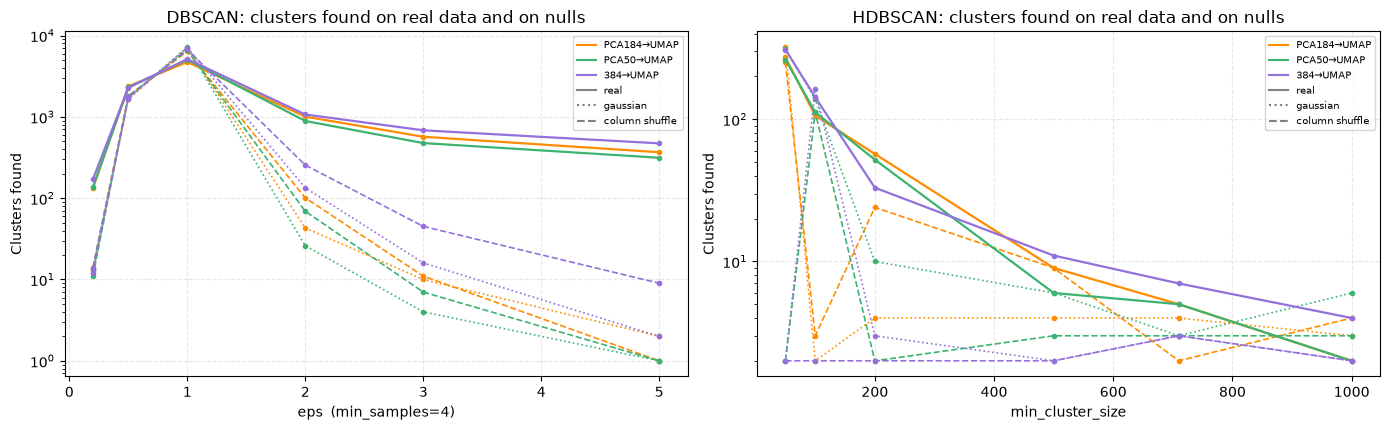


method   space            param  k real  k shuf  usable real  usable shuf  sil real  sil shuf
DBSCAN   PCA184→UMAP        0.2     132      14            0            0    -0.033    -0.006
DBSCAN   PCA184→UMAP        0.5    2372    1816            0            0    -0.105    -0.142
DBSCAN   PCA184→UMAP        1.0    4727    6385            8            5    -0.140    -0.156
DBSCAN   PCA184→UMAP        2.0    1006     101            9            1    -0.215    -0.168
DBSCAN   PCA184→UMAP        3.0     569      11            6            1    -0.243    -0.108
DBSCAN   PCA184→UMAP        5.0     367       1            4            1    -0.241       nan
DBSCAN   PCA50→UMAP         0.2     136      11            0            0    -0.092    -0.043
DBSCAN   PCA50→UMAP         0.5    2300    1792            0            0    -0.168    -0.214
DBSCAN   PCA50→UMAP         1.0    5044    6601            7            4    -0.218    -0.238
DBSCAN   PCA50→UMAP         2.0     889      69            

In [16]:
_density_inputs = {
    f"{_pca_label}→UMAP":   embeddings,
    f"{_pca50_label}→UMAP": embeddings_pca50,
    "384→UMAP":              embeddings_raw,
}

def _density_null_run(X, eps_values):
    """UMAP, scale normalise, then both density methods, exactly as section 2 runs them.

    The real run adds its own elbow to the sweep, so the null is handed the same eps values.
    Comparing at one parameter is the point, so the null does not get an elbow of its own.
    """
    scaled, _median = _normalize_scale(_fit_umap(X))
    g = cp.asarray(scaled, dtype=cp.float32)
    out = {}
    for eps in eps_values:
        out[("DBSCAN", eps)] = cuml.cluster.DBSCAN(
            eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean").fit_predict(g).get()
    for mcs in HDBSCAN_MIN_SIZES:
        out[("HDBSCAN", mcs)] = cuml.cluster.HDBSCAN(
            min_cluster_size=mcs, min_samples=HDBSCAN_MIN_SAMPLES,
            metric="euclidean").fit_predict(g).get()
    del g; cp.get_default_memory_pool().free_all_blocks()
    return out

density_null = {}
for _sname, _X in _density_inputs.items():
    _eps_values = sorted(dbscan_runs[_sname].keys())
    for _cond, _M in {"real": _X, **_make_nulls(_X)}.items():
        _runs = ({("DBSCAN", p): l for p, l in dbscan_runs[_sname].items()}
                 | {("HDBSCAN", p): l for p, l in hdbscan_runs[_sname].items()}
                 ) if _cond == "real" else _density_null_run(_M, _eps_values)
        for (_method, _param), _lbls in _runs.items():
            density_null[(_method, _sname, _param, _cond)] = _rand_eval(_lbls, _M)
    print(f"  {_sname}: done", flush=True)

_specs = [("DBSCAN", f"eps  (min_samples={DBSCAN_MIN_SAMPLES})", DBSCAN_EPS_VALUES),
          ("HDBSCAN", "min_cluster_size", HDBSCAN_MIN_SIZES)]

fig, axes = plt.subplots(1, len(_specs), figsize=(7 * len(_specs), 4.4), squeeze=False)
for ax, (method, xlabel, params) in zip(axes[0], _specs):
    for sname, colour in _space_colors.items():
        for cond, (ls, lw) in _cond_style.items():
            xs = [p for p in params if (method, sname, p, cond) in density_null]
            ys = [max(density_null[(method, sname, p, cond)]["k"], 0.5) for p in xs]
            ax.plot(xs, ys, ls, color=colour, linewidth=lw, marker="o", markersize=3)
    ax.set_yscale("log"); ax.set_xlabel(xlabel); ax.set_ylabel("Clusters found")
    ax.set_title(f"{method}: clusters found on real data and on nulls")
    ax.grid(linestyle="--", alpha=0.3)
    ax.legend(handles=[mlines.Line2D([], [], color=c, label=s) for s, c in _space_colors.items()]
                      + [mlines.Line2D([], [], color="grey", linestyle=ls, label=c)
                         for c, (ls, _lw) in _cond_style.items()], fontsize=7)
plt.tight_layout(); plt.show()

print(f"\n{'method':9s}{'space':15s}{'param':>7s}"
      f"{'k real':>8s}{'k shuf':>8s}{'usable real':>13s}{'usable shuf':>13s}"
      f"{'sil real':>10s}{'sil shuf':>10s}")
for method, _x, params in _specs:
    for sname in _density_inputs:
        for p in params:
            if (method, sname, p, "real") not in density_null:
                continue
            r = density_null[(method, sname, p, "real")]
            s = density_null[(method, sname, p, "column shuffle")]
            print(f"{method:9s}{sname:15s}{str(p):>7s}{r['k']:>8d}{s['k']:>8d}"
                  f"{r['usable']:>13d}{s['usable']:>13d}{r['sil']:>10.3f}{s['sil']:>10.3f}")


# Matched-k test: do the density methods beat a generic partition?

Silhouette falls as the number of clusters rises, on any data. Section 5 of the main notebook
compares each density run against a null at the same *parameter*, and the two sides then return
different cluster counts, so their silhouettes are not comparable.

This notebook fixes that. For every density run it takes the rows the method kept, counts the
clusters it found, and fits spherical KMeans on the same rows with the same k. Both partitions
then cover one row set at one granularity, so the difference between their silhouettes is a
fact about the partition.

`delta = silhouette(density) - silhouette(KMeans at the same k)`. A positive delta means the
density method found a better partition than a generic one of the same size.

This is a side test. Sample sizes are small and each size runs once.


In [17]:
# The matched-k test and the sweep below run at smaller sample sizes, so they rebuild their
# own subsamples. The corpus is reloaded here because the setup cell released it.
SAMPLE_SIZES = [10_000, 20_000]
N_INIT       = 5
DBSCAN_EPS   = [0.5, 1.0, 2.0, 3.0]
HDBSCAN_SIZE = [25, 50, 100, 200]

with pa_ipc.open_file(EMBEDDINGS) as reader:
    _t = reader.read_all()
_c   = _t["embedding"].combine_chunks()
FULL = (_c.flatten().to_numpy(zero_copy_only=False)
          .reshape(len(_c), -1).astype(np.float32, copy=False))
del _t, _c

def l2_normalize(X):
    return _l2_normalize(X)

def fit_umap(X):
    return _fit_umap(X)

def normalize_scale(X):
    """Scale so one unit is the median k-distance. _normalize_scale also returns the divisor."""
    return _normalize_scale(X)[0]

def column_shuffle(X, rng):
    return np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])]).astype(np.float32)

def cosine_silhouette(space, labels):
    ids = np.unique(labels)
    if len(ids) < 2:
        return float("nan")
    return float(silhouette_score(np.ascontiguousarray(space, dtype=np.float32),
                                  np.searchsorted(ids, labels).astype(np.int32), metric="cosine"))

print(f"corpus reloaded: {FULL.shape[0]:,} rows")


corpus reloaded: 317,945 rows


In [18]:
def matched_k_rows(density_labels, score_space):
    """Compare a density partition with spherical KMeans on the same rows at the same k.

    Noise is dropped first, so both partitions cover one row set. KMeans is then given the
    cluster count the density method chose, so neither side gains from a coarser split.
    """
    keep = density_labels != -1
    if keep.sum() < 10:
        return None
    lbl  = density_labels[keep]
    k    = len(np.unique(lbl))
    if k < 2:
        return None
    sub  = score_space[keep]
    sil_density = cosine_silhouette(sub, lbl)
    km, _c, _o  = spherical_kmeans(l2_normalize(sub), k, n_init=N_INIT, max_iter=300,
                                   tol=1e-6, random_state=RANDOM_SEED)
    sil_kmeans  = cosine_silhouette(sub, km)
    return dict(k=k, rows=int(keep.sum()), noise=float((~keep).mean()) * 100,
                sil_density=sil_density, sil_kmeans=sil_kmeans,
                delta=sil_density - sil_kmeans)

def density_runs(umap_space):
    g = cp.asarray(umap_space, dtype=cp.float32)
    out = {}
    for eps in DBSCAN_EPS:
        out[("DBSCAN", eps)] = cuml.cluster.DBSCAN(
            eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean").fit_predict(g).get()
    for mcs in HDBSCAN_SIZE:
        out[("HDBSCAN", mcs)] = cuml.cluster.HDBSCAN(
            min_cluster_size=mcs, min_samples=HDBSCAN_MIN_SAMPLES,
            metric="euclidean").fit_predict(g).get()
    del g; cp.get_default_memory_pool().free_all_blocks()
    return out

results = []
rng = np.random.default_rng(RANDOM_SEED)

for n in SAMPLE_SIZES:
    idx = (pl.DataFrame({"_": np.zeros(len(FULL), dtype=np.int8)}).with_row_index("_idx")
             .sample(n=n, seed=SUBSAMPLE_SEED)["_idx"].to_numpy())
    raw = FULL[idx]
    probe  = cuml.PCA(n_components=raw.shape[1]).fit(raw)
    ncomp  = int(np.searchsorted(np.cumsum(np.asarray(probe.explained_variance_ratio_)),
                                 PCA_VARIANCE)) + 1
    del probe
    pca = np.asarray(cuml.PCA(n_components=ncomp).fit_transform(raw))

    spaces = {f"PCA{ncomp}": pca, "384": raw}
    for space_name, X in spaces.items():
        for condition, M in (("real", X), ("column shuffle", column_shuffle(X, rng))):
            runs = density_runs(normalize_scale(fit_umap(M)))
            for (method, param), labels in runs.items():
                row = matched_k_rows(labels, M)
                if row is None:
                    continue
                results.append(dict(n=n, space=space_name, condition=condition,
                                    method=method, param=param, **row))
    print(f"  n={n:,} done ({ncomp} PCA dims)", flush=True)

results = pl.DataFrame(results)
print(f"\n{len(results)} configurations produced at least 2 clusters")


  n=10,000 done (182 PCA dims)


  n=20,000 done (183 PCA dims)



62 configurations produced at least 2 clusters


In [19]:
_real = results.filter(pl.col("condition") == "real").sort(["n", "method", "space", "param"])
print(f"{'n':>7s}{'method':>9s}{'space':>8s}{'param':>7s}{'k':>6s}{'rows':>8s}"
      f"{'sil density':>13s}{'sil kmeans@k':>14s}{'delta':>9s}")
for r in _real.iter_rows(named=True):
    print(f"{r['n']:>7,}{r['method']:>9s}{r['space']:>8s}{str(r['param']):>7s}{r['k']:>6d}"
          f"{r['rows']:>8,}{r['sil_density']:>13.3f}{r['sil_kmeans']:>14.3f}{r['delta']:>+9.3f}")

print("\ndelta by method, real data only:")
for method in ("DBSCAN", "HDBSCAN"):
    d = _real.filter(pl.col("method") == method)["delta"].to_numpy()
    print(f"  {method:8s} n={len(d):>2d}  median {np.median(d):+.3f}  "
          f"range {d.min():+.3f} to {d.max():+.3f}  |  positive in {int((d > 0).sum())} of {len(d)}")


      n   method   space  param     k    rows  sil density  sil kmeans@k    delta
 10,000   DBSCAN     384    0.5   264   2,182        0.150         0.263   -0.113
 10,000   DBSCAN     384    1.0   559   6,414       -0.011         0.101   -0.112
 10,000   DBSCAN     384    2.0   109   9,625       -0.116         0.061   -0.177
 10,000   DBSCAN     384    3.0    60   9,910       -0.132         0.054   -0.186
 10,000   DBSCAN  PCA182    0.5   241   2,135        0.217         0.301   -0.084
 10,000   DBSCAN  PCA182    1.0   507   6,284        0.037         0.121   -0.084
 10,000   DBSCAN  PCA182    2.0   122   9,579       -0.137         0.078   -0.216
 10,000   DBSCAN  PCA182    3.0    47   9,893       -0.156         0.075   -0.232
 10,000  HDBSCAN     384   25.0    23   9,250       -0.074         0.047   -0.121
 10,000  HDBSCAN     384   50.0     4  10,000       -0.072         0.051   -0.123
 10,000  HDBSCAN     384  100.0     2  10,000       -0.036         0.063   -0.099
 10,000  HDBSCAN

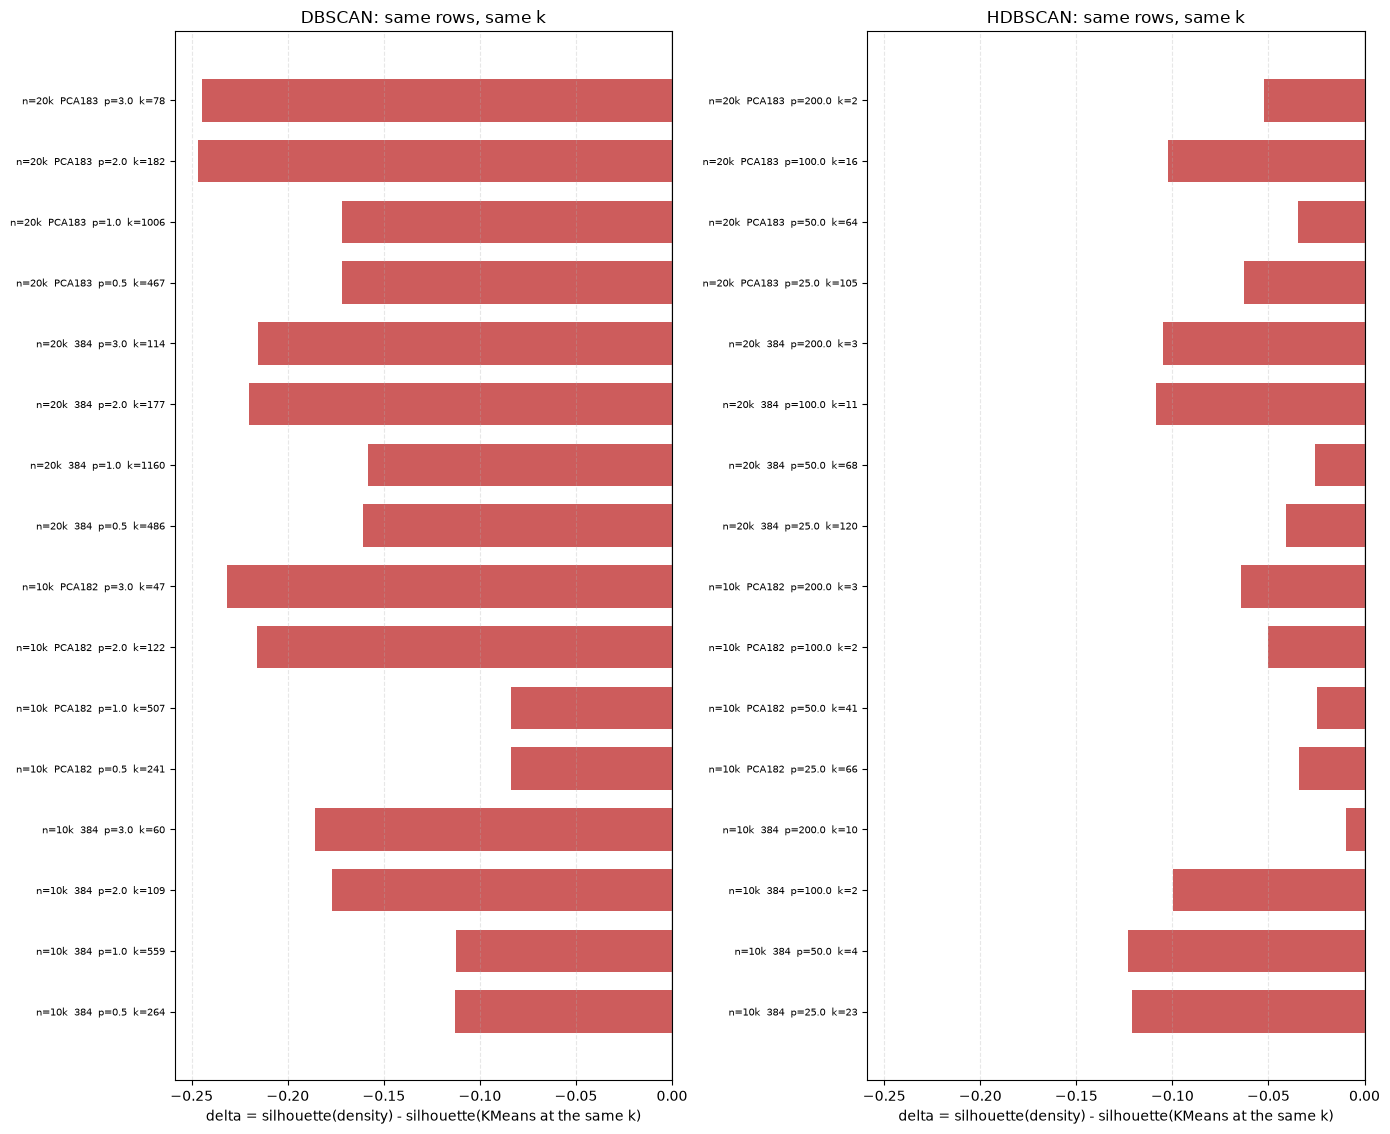

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(3.5, 0.32 * len(_real) + 1.2)), sharex=True)
for ax, method in zip(axes, ("DBSCAN", "HDBSCAN")):
    sub = _real.filter(pl.col("method") == method)
    labels = [f"n={r['n']//1000}k  {r['space']}  p={r['param']}  k={r['k']}"
              for r in sub.iter_rows(named=True)]
    deltas = sub["delta"].to_numpy()
    y = np.arange(len(deltas))
    ax.barh(y, deltas, height=0.7,
            color=["steelblue" if d > 0 else "indianred" for d in deltas])
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0, color="grey", linewidth=1)
    ax.set_xlabel("delta = silhouette(density) - silhouette(KMeans at the same k)")
    ax.set_title(f"{method}: same rows, same k")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()


## Reading this

`delta > 0` means the density partition separates the kept rows better than spherical KMeans
does at the same cluster count. `delta < 0` means a generic partition of the same size does
better, and the density method earns its silhouette from dropping rows as noise rather than
from finding a better split.

The `column shuffle` rows in `results` apply the same test to data with no clusters. They are
kept for reference and are not plotted.


## Fine sweep: does any setting reach a positive delta while keeping the rows?

The coarse test above found positive delta only where the method discarded three quarters of
the data. This sweep covers the parameters densely and plots delta against the fraction of rows
kept, so the trade-off is visible directly.

Documented starting points, marked on the plot:

| setting | value | source |
|---|---|---|
| UMAP `n_neighbors` | 30 | umap-learn, *Using UMAP for Clustering* |
| UMAP `min_dist` | 0.0 | umap-learn, *Using UMAP for Clustering* |
| UMAP `n_components` | 2 | umap-learn, *Using UMAP for Clustering* |
| HDBSCAN `min_samples` | 10 | umap-learn, same example |
| HDBSCAN `min_cluster_size` | 500 | umap-learn, same example, on 70,000 rows = 0.71% |
| DBSCAN `eps` | no numeric value given | scikit-learn: take the knee of the k-distance plot |
| DBSCAN `min_samples` | no numeric value given | scikit-learn: raise it on noisy data |

The main notebook uses `n_components=3`, so both 2 and 3 are swept. `eps` is expressed in units
of the median k-distance, so `eps = 1.0` is the scikit-learn anchor. HDBSCAN `min_cluster_size`
is swept in absolute counts; 0.71% of 20,000 rows is 142.


In [21]:
SWEEP_N          = 20_000
SWEEP_UMAP_DIMS  = [2, 3]                      # 2 is documented, 3 is what the pipeline uses
SWEEP_EPS        = np.round(np.arange(0.2, 3.01, 0.1), 2)
SWEEP_MCS        = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 142, 200, 300, 500]
SWEEP_MIN_SAMPLES = [HDBSCAN_MIN_SAMPLES, None]   # the documented value, and cuML's default

DOC_MARK = {("HDBSCAN", 500, 10): "umap-learn example",
            ("HDBSCAN", 142, 10): "umap-learn example, scaled to n"}
DOC_EPS  = 1.0                                 # median k-distance, the scikit-learn anchor

def fit_umap_dims(X, dims):
    return np.asarray(cuml.manifold.UMAP(
        n_components=dims, n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_SEED, metric="cosine").fit_transform(X))

_idx = (pl.DataFrame({"_": np.zeros(len(FULL), dtype=np.int8)}).with_row_index("_idx")
          .sample(n=SWEEP_N, seed=SUBSAMPLE_SEED)["_idx"].to_numpy())
_raw = FULL[_idx]
_probe = cuml.PCA(n_components=_raw.shape[1]).fit(_raw)
_ncomp = int(np.searchsorted(np.cumsum(np.asarray(_probe.explained_variance_ratio_)),
                             PCA_VARIANCE)) + 1
del _probe
_sweep_spaces = {f"PCA{_ncomp}": np.asarray(cuml.PCA(n_components=_ncomp).fit_transform(_raw)),
                 "384": _raw}

sweep = []
for space_name, X in _sweep_spaces.items():
    for dims in SWEEP_UMAP_DIMS:
        g = cp.asarray(normalize_scale(fit_umap_dims(X, dims)), dtype=cp.float32)
        for eps in SWEEP_EPS:
            lbls = cuml.cluster.DBSCAN(eps=float(eps), min_samples=DBSCAN_MIN_SAMPLES,
                                       metric="euclidean").fit_predict(g).get()
            row = matched_k_rows(lbls, X)
            if row:
                sweep.append(dict(space=space_name, dims=dims, method="DBSCAN",
                                  param=float(eps), min_samples=DBSCAN_MIN_SAMPLES, **row))
        for mcs in SWEEP_MCS:
            for ms in SWEEP_MIN_SAMPLES:
                kw = {"min_cluster_size": mcs, "metric": "euclidean"}
                if ms is not None:
                    kw["min_samples"] = ms
                lbls = cuml.cluster.HDBSCAN(**kw).fit_predict(g).get()
                row = matched_k_rows(lbls, X)
                if row:
                    sweep.append(dict(space=space_name, dims=dims, method="HDBSCAN",
                                      param=float(mcs), min_samples=ms, **row))
        del g; cp.get_default_memory_pool().free_all_blocks()
        print(f"  {space_name}, UMAP {dims}d: done", flush=True)

sweep = pl.DataFrame(sweep).with_columns(
    (pl.col("rows") / SWEEP_N * 100).alias("kept"))
print(f"\n{len(sweep)} configurations returned at least 2 clusters")

_pos = sweep.filter(pl.col("delta") > 0)
print(f"delta > 0 in {len(_pos)} of {len(sweep)}")
if len(_pos):
    print(f"  of those, rows kept: min {_pos['kept'].min():.1f}%  "
          f"median {_pos['kept'].median():.1f}%  max {_pos['kept'].max():.1f}%")
    print(f"  best delta at >= 80% of rows kept: ", end="")
    _best = _pos.filter(pl.col("kept") >= 80).sort("delta", descending=True)
    print("none" if not len(_best) else
          f"{_best['delta'][0]:+.3f} ({_best['method'][0]} param={_best['param'][0]}, "
          f"{_best['kept'][0]:.0f}% kept, k={_best['k'][0]})")


  PCA183, UMAP 2d: done


  PCA183, UMAP 3d: done


  384, UMAP 2d: done


  384, UMAP 3d: done



228 configurations returned at least 2 clusters
delta > 0 in 2 of 228
  of those, rows kept: min 3.6%  median 6.3%  max 8.9%
  best delta at >= 80% of rows kept: none


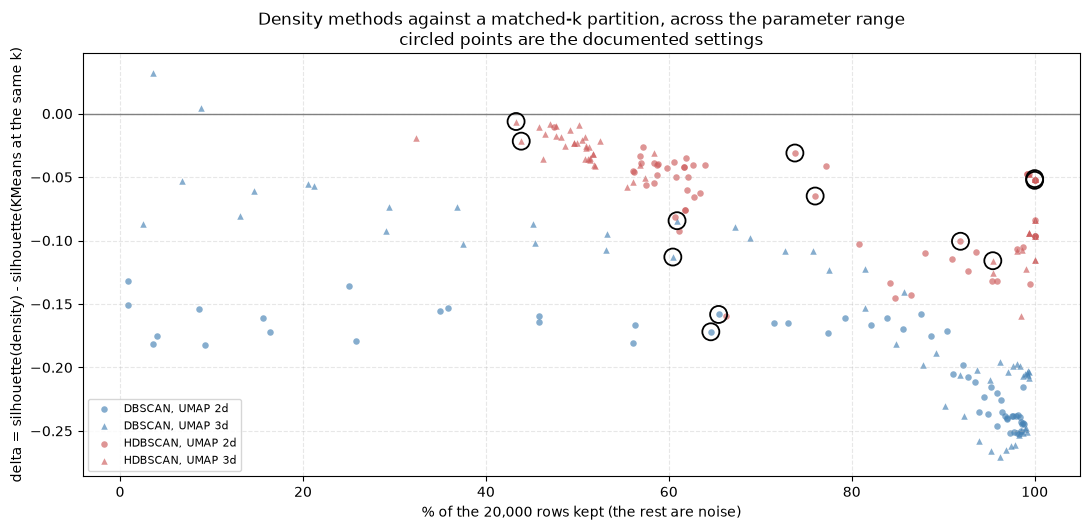

documented settings:
  DBSCAN   PCA183   UMAP 2d  param=   1.0  min_samples=   4  k=1006  kept= 64.6%  delta=-0.172   (scikit-learn k-distance anchor)
  HDBSCAN  PCA183   UMAP 2d  param= 142.0  min_samples=  10  k=   2  kept=100.0%  delta=-0.053   (umap-learn example, scaled to n)
  HDBSCAN  PCA183   UMAP 2d  param= 500.0  min_samples=  10  k=   4  kept= 76.0%  delta=-0.065   (umap-learn example)
  DBSCAN   PCA183   UMAP 3d  param=   1.0  min_samples=   4  k= 622  kept= 60.4%  delta=-0.113   (scikit-learn k-distance anchor)
  HDBSCAN  PCA183   UMAP 3d  param= 142.0  min_samples=  10  k=   2  kept=100.0%  delta=-0.051   (umap-learn example, scaled to n)
  HDBSCAN  PCA183   UMAP 3d  param= 500.0  min_samples=  10  k=   7  kept= 43.9%  delta=-0.022   (umap-learn example)
  DBSCAN   384      UMAP 2d  param=   1.0  min_samples=   4  k=1160  kept= 65.4%  delta=-0.158   (scikit-learn k-distance anchor)
  HDBSCAN  384      UMAP 2d  param= 142.0  min_samples=  10  k=   8  kept= 91.9%  delta=-0.

In [22]:
fig, ax = plt.subplots(figsize=(11, 5.4))
_marks = {2: "o", 3: "^"}
for method, colour in (("DBSCAN", "steelblue"), ("HDBSCAN", "indianred")):
    for dims, marker in _marks.items():
        sub = sweep.filter((pl.col("method") == method) & (pl.col("dims") == dims))
        if not len(sub):
            continue
        ax.scatter(sub["kept"], sub["delta"], s=22, marker=marker, color=colour, alpha=0.65,
                   linewidths=0, label=f"{method}, UMAP {dims}d")

for row in sweep.iter_rows(named=True):
    key = (row["method"], int(row["param"]), row["min_samples"])
    if key in DOC_MARK or (row["method"] == "DBSCAN" and abs(row["param"] - DOC_EPS) < 1e-6):
        ax.scatter([row["kept"]], [row["delta"]], s=150, facecolors="none",
                   edgecolors="black", linewidths=1.3, zorder=5)

ax.axhline(0, color="grey", linewidth=1)
ax.set_xlabel(f"% of the {SWEEP_N:,} rows kept (the rest are noise)")
ax.set_ylabel("delta = silhouette(density) - silhouette(KMeans at the same k)")
ax.set_title("Density methods against a matched-k partition, across the parameter range\n"
             "circled points are the documented settings")
ax.grid(linestyle="--", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("documented settings:")
for row in sweep.iter_rows(named=True):
    key = (row["method"], int(row["param"]), row["min_samples"])
    if key in DOC_MARK or (row["method"] == "DBSCAN" and abs(row["param"] - DOC_EPS) < 1e-6):
        note = DOC_MARK.get(key, "scikit-learn k-distance anchor")
        print(f"  {row['method']:8s} {row['space']:8s} UMAP {row['dims']}d  param={row['param']:>6.1f}"
              f"  min_samples={str(row['min_samples']):>4s}  k={row['k']:>4d}"
              f"  kept={row['kept']:5.1f}%  delta={row['delta']:+.3f}   ({note})")


## What this shows

**Density clustering does not work on this corpus. Use partitioning.**

Three measurements, all at n = 100,000 unless stated.

**The cluster count never settles.** DBSCAN on `PCA184→UMAP` returns 132 clusters at eps 0.2,
4,727 at eps 1.0, 1,006 at eps 2.0 and 367 at eps 5.0. A sharp peak, then decline. Density
structure produces a flat stretch instead, where the count holds while eps moves. No space and
no dimensionality gives one.

**Coherence is bought by discarding rows.** The best configuration of each method, scored in
the same space:

| method | rows kept | usable clusters | median cosine |
|---|---|---|---|
| spherical KMeans, k=160 | 100,000 | 115 | 0.528 |
| HDBSCAN, min_cluster_size=200 | 67,022 | 21 | 0.377 |
| DBSCAN, eps=2.0 | 93,662 | 9 | 0.262 |

DBSCAN keeps almost every row and its clusters fall apart. HDBSCAN holds together better and
drops a third of the corpus. Neither approaches the usable-cluster count of a partitioning fit.

**At a matched cluster count they lose outright.** Given the rows a density run kept and the
number of clusters it chose, spherical KMeans separates the same rows better in 32 of 32
configurations at the documented settings. Across 228 configurations in the fine sweep, only 2
beat it, and both keep under 9% of the corpus. None wins while keeping 80% or more.

**Why.** Section 5 of the main notebook measures the shape of the corpus: one large amorphous
mass with small tight satellites. Density methods separate on density contrast. The mass has
none, so a small eps shatters onto the satellites and abandons the mass, and a large eps
swallows everything. The satellites are real, and many of them are duplicate text rather than
topics. There is no setting between the two failures because there is no density structure in
the mass to find.
